
[CEO Worker] Running...
[History Worker] Running...

[Revenue Worker] Running...


========== MERGED RESULTS ==========
Worker     : CEO
Confidence : 0.9
Result     : **Lenovo Group Ltd. – Quick Leadership & Financial Snapshot (2023)**  

| Item | Details |
|------|---------|
| **Founder** | **Liu Chuanzhi** – a for...
-----------------------------------
Worker     : History
Confidence : 0.9
Result     : **Founder**

- **Liu Chuanzhi** – Liu Chuanzhi is widely recognized as the principal founder of Lenovo. In 1984, he and a small group of eleven engine...
-----------------------------------
Worker     : Revenue
Confidence : 0.9
Result     : **Lenovo Group Limited – Quick Financial & Founder Overview (as of 2023)**  

| Item | Details |
|------|---------|
| **Founder** | **Liu Chuanzhi** (...
-----------------------------------

========== SCHEDULER ==========
===========Schedular Printing===========
CEO        | Status: RUNNING      | Retry: 0/2 | Dependencies: []
History    | Status:

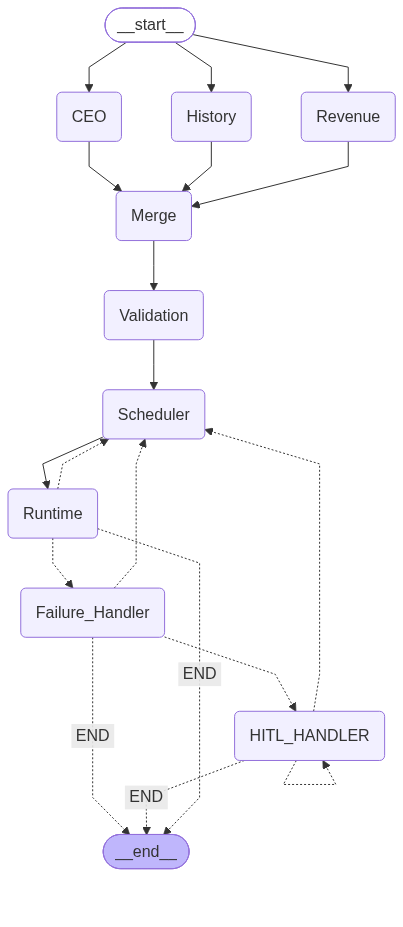

In [ ]:
import os
import operator
from typing import Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
# =========================================================
# 1. LLM
# =========================================================
# =========================================================
# 2. WORKER RESULT
# =========================================================
class WorkerResult(BaseModel):
    worker: str
    result: str
    confidence: float
# =========================================================
# 3. VALIDATION RESULT
# =========================================================
class ValidationResult(BaseModel):
    worker: str
    confidence: float
    route: str
    dependencies: list[str] = Field(
        default_factory=list
    )
    status: str = "PENDING"
    retry_count: int = 0
    max_retries: int = 2
    fallback: str = "HITL"
# =========================================================
# 4. GLOBAL STATE
# =========================================================
class NodeState(BaseModel):
    user_input: str = ""
    worker_results: Annotated[
        list[WorkerResult],
        operator.add
    ] = Field(
        default_factory=list
    )
    validation_results: list[
        ValidationResult
    ] = Field(
        default_factory=list
    )
    completed_tasks: Annotated[
        list[str],
        operator.add
    ] = Field(
        default_factory=list
    )

    hitl_decision: str | None = None
# =========================================================
# 5. HISTORY WORKER
# =========================================================

def history_worker(state: NodeState):

    print("\n[History Worker] Running...")

    response = llm.invoke(
        f"""
        You are a history expert.

        User query:
        {state.user_input}

        Provide accurate historical information.
        """
    )
    return {
        "worker_results": [
            WorkerResult(
                worker="History",
                result=response.content,
                confidence=0.90
            )
        ]
    }
# =========================================================
# 6. REVENUE WORKER
# =========================================================
def revenue_worker(state: NodeState):
    print("\n[Revenue Worker] Running...")
    response = llm.invoke(
        f"""
        You are a financial expert.
        User query:
        {state.user_input}
        Provide the relevant revenue and financial information.
        """
    )
    return {
        "worker_results": [
            WorkerResult(
                worker="Revenue",
                result=response.content,
                confidence=0.90
            )
        ]
    }


# =========================================================
# 7. CEO WORKER
# =========================================================

def ceo_worker(state: NodeState):

    print("\n[CEO Worker] Running...")

    response = llm.invoke(
        f"""
        You are a corporate leadership expert.

        User query:
        {state.user_input}

        Provide information about the founder,
        CEO and corporate leadership.
        """
    )

    return {
        "worker_results": [
            WorkerResult(
                worker="CEO",
                result=response.content,
                confidence=0.90
            )
        ]
    }
# =========================================================
# 8. MERGE NODE
# =========================================================
def merge_node(state: NodeState):

    print("\n========== MERGED RESULTS ==========")

    for result in state.worker_results:

        print(
            f"Worker     : {result.worker}"
        )

        print(
            f"Confidence : {result.confidence}"
        )

        print(
            f"Result     : {result.result[:150]}..."
        )

        print("-----------------------------------")
    return {}
# =========================================================
# 9. VALIDATION NODE
# =========================================================
def validation_node(state: NodeState):
    validation_results = []
    for result in state.worker_results:
        # -----------------------------
        # ROUTING
        # -----------------------------
        if result.confidence >= 0.90:
            route = "Writer"
        elif result.confidence >= 0.60:
            route = "Planner"
        else:
            route = "HITL"
        # -----------------------------
        # DEPENDENCY
        # -----------------------------
        dependencies = []
        # For Day 39 testing we keep
        # dependencies empty.
        #
        # Example:
        #
        # if result.worker == "Revenue":
        #     dependencies = ["FinanceReview"]
        validation_results.append(
            ValidationResult(
                worker=result.worker,
                confidence=result.confidence,
                route=route,
                dependencies=dependencies,
                status="PENDING"
            )
        )
    return {
        "validation_results": validation_results
    }
# =========================================================
# 10. SCHEDULER
# =========================================================
def scheduler(state: NodeState):
    concurrency_limit = 2
    ready_tasks = []
    print("\n========== SCHEDULER ==========")
    # =====================================================
    # DEPENDENCY CHECK
    # =====================================================
    for task in state.validation_results:
        dependencies_satisfied = all(
            dependency in state.completed_tasks
            for dependency in task.dependencies)
        if dependencies_satisfied:
            task.status = "READY"
            ready_tasks.append(task)
        else:
            task.status = "BLOCKED"
    # =====================================================
    # PRIORITY
    # =====================================================
    ready_tasks.sort(
        key=lambda task: task.confidence,
        reverse=True
    )
    # =====================================================
    # CONCURRENCY
    # =====================================================
    running_tasks = ready_tasks[
        :concurrency_limit
    ]
    waiting_tasks = ready_tasks[
        concurrency_limit:
    ]
    # =====================================================
    # RUNNING
    # =====================================================
    for task in running_tasks:
        task.status = "RUNNING"
    # =====================================================
    # WAITING
    # =====================================================
    for task in waiting_tasks:
        task.status = "WAITING"
    # =====================================================
    # PRINT
    # =====================================================
    print("===========Schedular Printing===========")
    for task in state.validation_results:
        print(
            f"{task.worker:10} | "
            f"Status: {task.status:12} | "
            f"Retry: {task.retry_count}/"
            f"{task.max_retries} | "
            f"Dependencies: {task.dependencies}"
        )
    return {
        "validation_results": state.validation_results
    }
# =========================================================
# 11. RUNTIME
# =========================================================
def runtime_execute(state: NodeState):
    print("\n========== RUNTIME ==========")
    for task in state.validation_results:
        # Runtime ONLY executes RUNNING tasks
        if task.status != "RUNNING":
            continue
        print(
            f"Executing: {task.worker}"
        )
        execution_success = False
        if execution_success:
            task.status = "SUCCESS"
            print(
                f"{task.worker} → SUCCESS"
            )
        else:
            task.status = "FAILED"
            print(
                f"{task.worker} → FAILED"
            )
    return {
        "validation_results": state.validation_results
    }
# =========================================================
# 12. ROUTER AFTER RUNTIME
# =========================================================
def route_after_runtime(state: NodeState):
    for task in state.validation_results:
        if task.status == "FAILED":
            return "Failure_Handler"
        if task.status in [
            "READY",
            "WAITING"
        ]:
          return "Scheduler"
    return "END"
# =========================================================
# 13. FAILURE HANDLER
# =========================================================
def failure_handler(state: NodeState):
    print("\n========== FAILURE HANDLER ==========")
    for task in state.validation_results:
        if task.status != "FAILED":
            continue
        # =================================================
        # RETRY AVAILABLE
        # =================================================
        if task.retry_count < task.max_retries:
            task.retry_count += 1
            task.status = "READY"
            print(
                f"{task.worker} → RETRY "
                f"{task.retry_count}/"
                f"{task.max_retries}"
            )
            return {
                "validation_results":
                state.validation_results
            }
        # =================================================
        # RETRY LIMIT REACHED
        # =================================================
        else:
            task.status = "HITL_READY"

            print(
                f"{task.worker} → HITL_READY"
            )
            return {
                "validation_results":
                state.validation_results
            }

    return {
        "validation_results":
        state.validation_results
    }
# =========================================================
# 14. ROUTER AFTER FAILURE
# =========================================================
def route_after_failure(state: NodeState):
    for task in state.validation_results:
        if task.status == "READY":
            return "Scheduler"
        if task.status == "HITL_READY":
            return "HITL_HANDLER"
    return "END"


# =========================================================
# 15. HITL HANDLER
# =========================================================

def hitl_handler(state: NodeState):
    print("\n========== HITL ==========")
    decision = interrupt(
        "Task requires human decision. "
        "Choose: APPROVED, RETRY, or REJECTED")
    for task in state.validation_results:
        if task.status != "HITL_READY":
            continue
        # =================================================
        # APPROVED
        # =================================================
        if decision == "APPROVED":
            task.status = "SUCCESS"
            print(
                f"{task.worker} → APPROVED → SUCCESS"
            )
            return {
                "validation_results":
                state.validation_results,
                "completed_tasks":
                [task.worker],
                "hitl_decision":
                decision
            }
        # =================================================
        # RETRY
        # =================================================
        elif decision == "RETRY":
            task.status = "READY"
            print(
                f"{task.worker} → HUMAN RETRY"
            )

            return {
                "validation_results":
                state.validation_results,

                "hitl_decision":
                decision
            }


        # =================================================
        # REJECTED
        # =================================================

        elif decision == "REJECTED":

            task.status = "REJECTED"

            print(
                f"{task.worker} → REJECTED"
            )

            return {
                "validation_results":
                state.validation_results,

                "hitl_decision":
                decision
            }


        # =================================================
        # INVALID DECISION
        # =================================================

        else:

            task.status = "HITL_READY"

            return {
                "validation_results":
                state.validation_results,

                "hitl_decision":
                "INVALID"
            }


# =========================================================
# 16. ROUTER AFTER HITL
# =========================================================

def route_after_hitl(state: NodeState):

    for task in state.validation_results:

        if task.status == "READY":

            return "Scheduler"


        if task.status == "HITL_READY":

            return "HITL_HANDLER"


        if task.status in [
            "SUCCESS",
            "REJECTED"
        ]:

            return "END"


    return "END"


# =========================================================
# 17. BUILD GRAPH
# =========================================================

graph = StateGraph(NodeState)


# =========================================================
# NODES
# =========================================================

graph.add_node(
    "History",
    history_worker
)

graph.add_node(
    "Revenue",
    revenue_worker
)

graph.add_node(
    "CEO",
    ceo_worker
)

graph.add_node(
    "Merge",
    merge_node
)

graph.add_node(
    "Validation",
    validation_node
)

graph.add_node(
    "Scheduler",
    scheduler
)

graph.add_node(
    "Runtime",
    runtime_execute
)

graph.add_node(
    "Failure_Handler",
    failure_handler
)

graph.add_node(
    "HITL_HANDLER",
    hitl_handler
)


# =========================================================
# FAN OUT
# =========================================================

graph.add_edge(
    START,
    "History"
)

graph.add_edge(
    START,
    "Revenue"
)

graph.add_edge(
    START,
    "CEO"
)


# =========================================================
# FAN IN
# =========================================================

graph.add_edge(
    "History",
    "Merge"
)

graph.add_edge(
    "Revenue",
    "Merge"
)

graph.add_edge(
    "CEO",
    "Merge"
)


# =========================================================
# VALIDATION
# =========================================================

graph.add_edge(
    "Merge",
    "Validation"
)


# =========================================================
# SCHEDULER
# =========================================================

graph.add_edge(
    "Validation",
    "Scheduler"
)


# =========================================================
# SCHEDULER → RUNTIME
# =========================================================

graph.add_edge(
    "Scheduler",
    "Runtime"
)


# =========================================================
# RUNTIME → CONDITIONAL ROUTING
# =========================================================

graph.add_conditional_edges(
    "Runtime",
    route_after_runtime,
    {
        "Failure_Handler":
            "Failure_Handler",

        "Scheduler":
            "Scheduler",

        "END":
            END
    }
)
# =========================================================
# FAILURE HANDLER → CONDITIONAL ROUTING
# =========================================================
graph.add_conditional_edges(
    "Failure_Handler",
    route_after_failure,
    {
        "Scheduler":
            "Scheduler",

        "HITL_HANDLER":
            "HITL_HANDLER",

        "END":
            END
    }
)
# =========================================================
# HITL → CONDITIONAL ROUTING
# =========================================================
graph.add_conditional_edges(
    "HITL_HANDLER",
    route_after_hitl,
    {
        "Scheduler":
            "Scheduler",
        "HITL_HANDLER":
            "HITL_HANDLER",
        "END":
            END
    }
)
# =========================================================
# 18. CHECKPOINTER
# =========================================================

checkpointer = InMemorySaver()


# =========================================================
# 19. COMPILE
# =========================================================

app = graph.compile(
    checkpointer=checkpointer
)
# =========================================================
# 20. THREAD
# =========================================================
config = {
    "configurable": {
        "thread_id": "day39-thread-001"
    }
}
# =========================================================
# 21. FIRST EXECUTION
# =========================================================
result_1 = app.invoke(
    {
        "user_input":
        "Who is the founder of Lenovo and what was "
        "the revenue of the company in 2023?"
    },
    config=config
)
print("\n========== FIRST EXECUTION ==========")
print(result_1)

# =========================================================
# 22. HUMAN DECISION
# =========================================================
#
# IMPORTANT:
#
# This line is executed ONLY after the workflow
# reaches interrupt() and pauses.
#
# For example:
#
# human_decision = "RETRY"
#
# or:
#
# human_decision = "APPROVED"
#
# or:
#
# human_decision = "REJECTED"
#
# =========================================================
human_decision = "RETRY"
# =========================================================
# 23. RESUME SAME THREAD
# =========================================================
result_2 = app.invoke(
    Command(
        resume=human_decision
    ),
    config=config
)
print("\n========== AFTER HUMAN DECISION ==========")
print(result_2)
# =========================================================
# 24. FINAL STATE
# =========================================================
print("\n========== FINAL STATE ==========")
final_state = app.get_state(config)
print(
    "Next:",
    final_state.next
)
print(
    "Values:",
    final_state.values
)
print(
    "Completed Tasks:",
    final_state.values.get(
        "completed_tasks",
        []
    )
)
for task in final_state.values.get(
    "validation_results",
    []
):

    print(
        f"{task.worker:10} | "
        f"Status: {task.status:12} | "
        f"Retry: {task.retry_count}/"
        f"{task.max_retries}"
    )
app